In [124]:
import meep as mp
from meep.materials import Ag
import numpy as np
import matplotlib.pyplot as plt

fac_decay = 1e-6
# Parameters for the flower shape (from your polar plot)
rmin =  1.118169e-01 
rmax =  2.195406e-01 
rm = (rmax + rmin) / 2
c = rmax - rm + 1e-16
alpha = 1.316129e+01 
beta = 0.
s = 1.148135e+01
thickness = 0.02
a = 0.5
Nf = 3  # Number of petals (6-fold symmetry)
sz = 2
nfreq = 100     # Number of frequency points for the spectrum

# Function to check if a point (x, y) is inside the flower
def is_inside_flower(x, y, z):

    # 
    if z > thickness/2 or z < - thickness/2:
        return True
   
    # Convert to polar coordinates
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    if theta < 0:
        theta += 2 * np.pi  # Ensure theta is in [0, 2π]

    # Check if r is within the radial bounds
    if r < rmin or r > rmax:
        return False
     # Compute the angular boundaries for the petal
    rv = r
    theta1 = s * np.sqrt(c**2 - (rv - rm)**2) + alpha * rv + beta * rv**2
    theta2 = -s * np.sqrt(c**2 - (rv - rm)**2) + alpha * rv + beta * rv**2

    # Normalize theta to the first petal and check all petals
    for i in range(Nf):
        dtheta = i * 2 * np.pi / Nf
        # Shift theta to the current petal
        theta_shifted = (theta - dtheta) % (2 * np.pi)
        if theta_shifted < 0:
            theta_shifted += 2 * np.pi

        # Check if theta_shifted is between theta2 and theta1
        # theta2 is the lower bound, theta1 is the upper bound
        if theta2 <= theta_shifted <= theta1:
            return True

    return False

# Meep material function
def flower_material(p):
    x, y, z = p.x, p.y, p.z
    if is_inside_flower(x, y, z):
        return mp.Medium(epsilon=1)  # Dielectric constant inside flower
    else:
        return Ag  # Vacuum outside

# Simulation parameters
cell_size = mp.Vector3(a, a, sz)  # 2D simulation (z=0)
resolution = 100  # pixels per unit length
boundary_layers = [mp.Absorber(thickness=0.5,direction=mp.Z)]  # Perfectly matched layers

# Geometry with custom material
geometry = [
    mp.Block(
        size=cell_size,
        center=mp.Vector3(),
        material=flower_material
    )
]

# Source
fcen = 1/0.6
df = 1
sources_RCP = [
    mp.Source(
        src=mp.GaussianSource(frequency=fcen,fwidth=df),
        component=mp.Ex,
        center=mp.Vector3(0, 0, -0.2),
        size=mp.Vector3(a, a, 0),  # Spans the xy-plane of the unit cell
        amplitude=1
    ),
        mp.Source(
        src=mp.GaussianSource(frequency=fcen,fwidth=df),
        component=mp.Ey,
        center=mp.Vector3(0, 0, -0.2),
        size=mp.Vector3(a, a, 0),  # Spans the xy-plane of the unit cell
        amplitude=1j
    )

]
sources_LCP = [
    mp.Source(
        src=mp.GaussianSource(frequency=fcen,fwidth=df),
        component=mp.Ex,
        center=mp.Vector3(0, 0, -0.2),
        size=mp.Vector3(a, a, 0),  # Spans the xy-plane of the unit cell
        amplitude=1
    ),
        mp.Source(
        src=mp.GaussianSource(frequency=fcen,fwidth=df),
        component=mp.Ey,
        center=mp.Vector3(0, 0, -0.2),
        size=mp.Vector3(a, a, 0),  # Spans the xy-plane of the unit cell
        amplitude=-1j
    )

]

In [125]:
# sim without structure
sim = mp.Simulation(
    cell_size=cell_size,
    resolution=resolution,
    boundary_layers=boundary_layers,
    sources=sources_RCP,
    k_point=mp.Vector3(0, 0, 0),
    geometry=[]
)


# Add flux monitor for  incident
flux_inci = sim.add_flux(
    fcen,
    df,
    nfreq,
    mp.FluxRegion(
        center=mp.Vector3(0, 0, 0.2),
        size=mp.Vector3(a, a, 0)
    )
)
# Run the simulation
# Run the simulation
sim.run(until_after_sources=mp.stop_when_fields_decayed(5, mp.Ex, mp.Vector3(), fac_decay ))
# Get the incident flux data
incident_flux = mp.get_fluxes(flux_inci)

-----------
Initializing structure...
time for choose_chunkdivision = 1.69277e-05 s
Working in 3D dimensions.
Computational cell is 0.5 x 0.5 x 2 with resolution 100
time for set_epsilon = 0.880843 s
time for set_conductivity = 0.018353 s
time for set_conductivity = 0.018353 s
time for set_conductivity = 0.0183671 s
time for set_conductivity = 0.0196381 s
time for set_conductivity = 0.019588 s
time for set_conductivity = 0.0195761 s
-----------
on time step 401 (time=2.005), 0.0099943 s/step
on time step 834 (time=4.17), 0.00925248 s/step
field decay(t = 5.005): 0.22967493381093715 / 0.22967493381093715 = 1.0
on time step 1266 (time=6.33), 0.00926567 s/step
on time step 1698 (time=8.49), 0.00926636 s/step
field decay(t = 10.01): 0.2504807234217252 / 0.2504807234217252 = 1.0
on time step 2131 (time=10.655), 0.00924581 s/step
on time step 2566 (time=12.83), 0.00921519 s/step
on time step 2999 (time=14.995), 0.0092477 s/step
field decay(t = 15.015): 4.908790566897829e-11 / 0.2504807234217

In [126]:
# Step 2: Simulation with the structure to compute transmitted flux
# sim_film.reset_meep()
sim_film = mp.Simulation(
    cell_size=cell_size,
    resolution=resolution,
    boundary_layers=boundary_layers,
    sources=sources_RCP,
    k_point=mp.Vector3(0, 0, 0),
    geometry=geometry,  # Include the film and hole,
    extra_materials = [Ag] # !!!! required when using self-defined material
)

In [4]:
# Add flux monitor at the same position as in the empty simulation
flux_trans = sim_film.add_flux(
    fcen,
    df,
    nfreq,
    mp.FluxRegion(
        center=mp.Vector3(0, 0, 0.2),
        size=mp.Vector3(a, a, 0)
    )
)
# Run the simulation
import time
start_time = time.perf_counter()
sim_film.run(until_after_sources=mp.stop_when_fields_decayed(5, mp.Ex, mp.Vector3(0,0,-0.2), fac_decay ))
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")
# Get the transmitted flux data
transmitted_flux = mp.get_fluxes(flux_trans)

-----------
Initializing structure...
time for choose_chunkdivision = 2.31266e-05 s
Working in 3D dimensions.
Computational cell is 0.5 x 0.5 x 2 with resolution 100
     block, center = (0,0,0)
          size (0.5,0.5,2)
          axes (1,0,0), (0,1,0), (0,0,1)
subpixel-averaging is 15.6846% done, 21.6738 s remaining
subpixel-averaging is 31.3693% done, 8.78005 s remaining
subpixel-averaging is 47.2453% done, 4.50657 s remaining
subpixel-averaging is 63.3126% done, 2.331 s remaining
subpixel-averaging is 79.5712% done, 1.03847 s remaining
subpixel-averaging is 95.8298% done, 0.176141 s remaining
subpixel-averaging is 16.2584% done, 20.7459 s remaining
subpixel-averaging is 32.3257% done, 8.39507 s remaining
subpixel-averaging is 48.5843% done, 4.26123 s remaining
subpixel-averaging is 64.8428% done, 2.18996 s remaining
subpixel-averaging is 81.1014% done, 0.933837 s remaining
subpixel-averaging is 97.36% done, 0.108571 s remaining
subpixel-averaging is 16.4497% done, 20.3268 s remaini

     block, center = (0,0,0)
          size (0.5,0.5,2)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (0.5,0.5,2)
          axes (1,0,0), (0,1,0), (0,0,1)


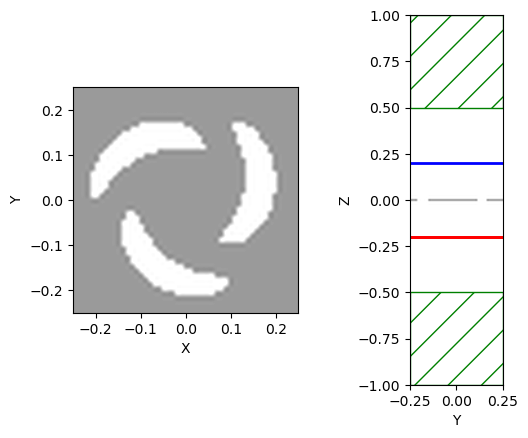

In [5]:
import matplotlib
import matplotlib.pyplot as plt
output_plane_yz = mp.Volume(
        center=mp.Vector3(0, 0, 0),  # Center of the plane
        size=mp.Vector3(0, a, sz)     # Size: full x and y, zero thickness in z
    )
output_plane_xy = mp.Volume(
        center=mp.Vector3(0, 0, 0),  # Center of the plane
        size=mp.Vector3(a, a, 0)     # Size: full x and y, zero thickness in z
    )
plt.subplot(1,2,1)
sim_film.plot2D( output_plane = output_plane_xy,eps_parameters={'cmap':'gray','vmin':-25,'vmax':1,'alpha':0.75})
plt.subplot(1,2,2)
sim_film.plot2D( output_plane = output_plane_yz,eps_parameters={'cmap':'gray','vmin':-25,'vmax':1,'alpha':0.75})
plt.show()

In [6]:
# Compute the transmission spectrum
transmission = [t / i for t, i in zip(transmitted_flux, incident_flux)]

# Extract transmission at the center frequency
flux_freqs = mp.get_flux_freqs(flux_trans)
index = np.argmin(np.abs(np.array(flux_freqs) - fcen))
transmission_at_fcen = transmission[index]

Transmission at f = 1.6666666666666667 (lambda = 600 nm): 0.05648112819317603


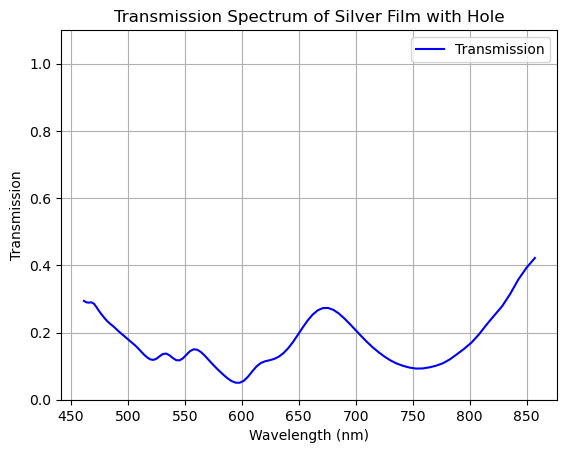

In [7]:
# Output the result
print(f"Transmission at f = {fcen} (lambda = 600 nm): {transmission_at_fcen}")

# Optional: Plot the transmission spectrum
import matplotlib.pyplot as plt
plt.plot(1000/ np.array(flux_freqs), transmission, 'b-', label='Transmission')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.ylim([0,1.1])
plt.title('Transmission Spectrum of Silver Film with Hole')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
## LCP run
sim_film.restart_fields()
sim_film.clear_dft_monitors()
sim_film.change_sources([])
sim_film.change_sources(sources_LCP)
# Add flux monitor at the same position as in the empty simulation
flux_trans = sim_film.add_flux(
    fcen,
    df,
    nfreq,
    mp.FluxRegion(
        center=mp.Vector3(0, 0, 0.2),
        size=mp.Vector3(a, a, 0)
    )
)

sim_film._evaluate_dft_objects() ## Test: sim.run also do this after each step. This line does eva dft at aeroth step.

# Run the simulation
sim_film.run(until_after_sources=mp.stop_when_fields_decayed(5, mp.Ex, mp.Vector3(0,0,-0.2), fac_decay ))
# Get the transmitted flux data
transmitted_flux_LCP = mp.get_fluxes(flux_trans)

on time step 84 (time=0.42), 0.0476266 s/step
on time step 168 (time=0.84), 0.0476655 s/step
on time step 252 (time=1.26), 0.0476336 s/step
on time step 336 (time=1.68), 0.047628 s/step
on time step 421 (time=2.105), 0.0476108 s/step
on time step 521 (time=2.605), 0.0401033 s/step
on time step 624 (time=3.12), 0.0389959 s/step
on time step 727 (time=3.635), 0.0390542 s/step
on time step 830 (time=4.15), 0.0390034 s/step
on time step 933 (time=4.665), 0.0390218 s/step
field decay(t = 5.005): 0.38538100095641814 / 0.38538100095641814 = 1.0
on time step 1036 (time=5.18), 0.0390046 s/step
on time step 1139 (time=5.695), 0.039014 s/step
on time step 1242 (time=6.21), 0.038985 s/step
on time step 1345 (time=6.725), 0.0390184 s/step
on time step 1448 (time=7.24), 0.0391956 s/step
on time step 1551 (time=7.755), 0.039 s/step
on time step 1654 (time=8.27), 0.0390677 s/step
on time step 1757 (time=8.785), 0.0389908 s/step
on time step 1860 (time=9.3), 0.0390311 s/step
on time step 1963 (time=9.8

In [9]:
# Compute the transmission spectrum
transmission_LCP = [t / i for t, i in zip(transmitted_flux_LCP, incident_flux)]

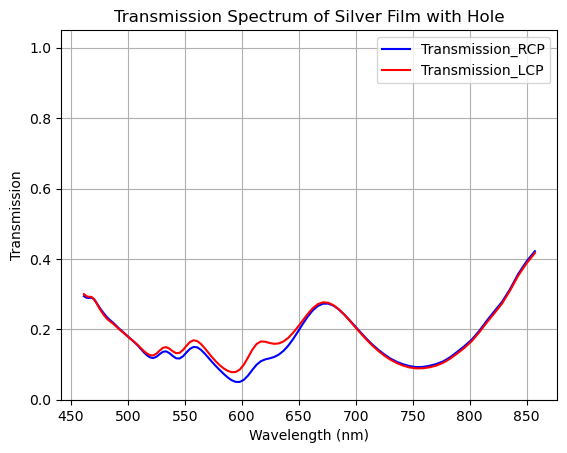

In [10]:

# Optional: Plot the transmission spectrum
import matplotlib.pyplot as plt
plt.plot(1000/ np.array(flux_freqs), transmission, 'b-', label='Transmission_RCP')
plt.plot(1000/ np.array(flux_freqs), transmission_LCP, 'r-', label='Transmission_LCP')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.ylim([0,1.05])
plt.title('Transmission Spectrum of Silver Film with Hole')
plt.legend()
plt.grid(True)
plt.show()

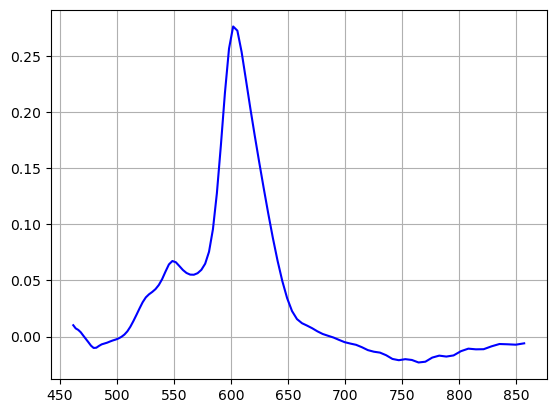

In [11]:
plt.plot(1000/ np.array(flux_freqs), -(np.array(transmission) - np.array(transmission_LCP))/(np.array(transmission) + np.array(transmission_LCP)), 'b-', label='Transmission_RCP')
plt.grid()

In [17]:
Ag.epsilon(1/0.6)[0][0]

(-12.656904332017437+0.9922997298661321j)

In [27]:
Ag.epsilon(1/1.55)[0][0]

(-103.33245587836095+8.130148047419626j)

With the Drude model in MEEP,
$$\epsilon (f) = \epsilon_{\infty} - \frac{\sigma f_n^2}{f(f + i  \gamma_n)} $$
We want to simulate a material of $\epsilon = \epsilon_1 + i \epsilon_2$ at $ f = f_t$ with the LD model. We have
$$\epsilon_1 + i \epsilon_2 = \epsilon_{\infty} - \frac{\sigma f_n^2}{f_t(f_t + i  \gamma_n)},$$
Set $\epsilon_\infty = 1$ and treat $\sigma f_n^2$ as $A$ and $\gamma_n$ as $B$
$$\epsilon_1 + i \epsilon_2 = 1 - \frac{A}{f_t(f_t + i  B)} = 1 - \frac{A(f_t-iB)}{f_t(f_t^2 +B^2)}$$
The solution is
$$A = f_t^2 \frac{(1-\epsilon_1)^2+\epsilon_2^2 }{(1-\epsilon_1)}$$ and
$$B = f_t \frac{\epsilon_2}{1-\epsilon_1}$$

In [123]:
ft = 1 / 0.6
eps1 = np.real(Ag.epsilon(ft)[0][0])
eps2 = np.imag(Ag.epsilon(ft)[0][0])
A =  ft**2 * (eps2**2 + (1-eps1)**2)/(1-eps1)
B = ft * eps2/(1-eps1)
susceptibilities = [mp.DrudeSusceptibility(frequency = 1, gamma= B, sigma =  A)]

Ag_self_define = mp.Medium(epsilon= 1 , E_susceptibilities=susceptibilities)

In [122]:
Ag_self_define.epsilon(ft)[0][0] - eps1 - 1j * eps2

-1.1102230246251565e-16j

In [127]:
index = np.argmin(np.abs(np.array(flux_freqs) - fcen))
transmission_at_fcen = transmission[index]

In [131]:
flux_freqs[index]

1.6616161616161618